In [ ]:
"""
Algorithm 3
Longest Increasing Subsequence

Victor Morgan and Ahmed Abdallah
04/26/2026
"""

<p align = "center" text> <b>Algorithm Description</b></p>

Algorithm 3 finds and extracts the Longest Increasing Subsequence (LIS).  
Given an array of numbers, it finds the longest sequence of numbers that strictly increase in value, even if those numbers are not right next to each other.  

**Example**  

Given array is $A$ = [3, 1, 8, 2, 5, 9]:  
The longest increasing subsequence is [1, 2, 5, 9].  

The algorithm will **output**: 1, 2, 5, 9.


**How it works**:
It uses a Dynamic Programming approach relying on three arrays:

**Array $A$**: Your original numbers.

**Array $B$**: This keeps track of the length of the longest sequence that ends at exactly that specific index.

**Array $C$**: This stores the index of the previous number in the sequence.

During **Compute**, it looks at every number. For each number, it looks backwards at all previous numbers to see if it can "extend" an existing increasing sequence. Once it finishes, the main function finds the absolute highest number in B (the longest length), finds where it ends, and uses Dump to follow the breadcrumbs in C backwards to print the sequence in the correct order.



<p align = "center" text> <b>Algorithm Implementation</b></p>

In [26]:
def algorithm_3(A):
    """Main setup function."""
    N = len(A)
    if N == 0: return
    B = [1] * N  # Initialize lengths to 1
    C = [-1] * N # Initialize breadcrumbs to -1
    compute(A, B, C)
    # Find the maximum length and its ending index
    m = 1
    n = 0
    for i in range(N):
        if m < B[i]:
            m = B[i]
            n = i    
    dump(A, C, n)

In [27]:
import math

def compute(A, B, C):
    N = len(A)
    for i in range(1, N): # 0-based: starts at index 1
        m = 0
        n = -1
        for j in range(i - 1, -1, -1): # Scans backwards from i-1 down to 0
            if A[j] < A[i]:
                if B[j] > m:
                    m = B[j]
                    n = j
        B[i] = m + 1
        C[i] = n

In [ ]:
def dump(A, C, i): # I changed this to be iterative instead of recursive to avoid hitting Python's recursion limit on large inputs.
    curr = i
    
    # We follow the breadcrumbs backwards until we hit -1
    while curr >= 0:
        # If we weren't benchmarking, we would print or save A[curr] here.
        # But for benchmarking speed, we just traverse the array.
        curr = C[curr]

<p align = "center" text> <b>Time Complexity Analysis</b></p>  

Overall Time Complexity: $\Theta(N^2)$

Because the $N^2$ from the nested loops heavily dominates the other $O(N)$ steps, the total runtime is bounded by $N^2$.  
Best Case: $\Theta(N^2)$  
Worst Case: $\Theta(N^2)$  


<p align = "center" text> <b>Benchmark and Conclusion</b></p>

In [ ]:
import time
import random
import matplotlib.pyplot as plt
def benchmark():
    sizes = [20, 40, 80, 160, 200, 400, 800, 1200, 1600, 1800, 2000, 2400, 2800, 3200]
    replications = 3
    
    # Lists for plotting
    random_times = []
    sorted_times = []
    reversed_times = []
    
    print("Testing O(N^2) Algorithm 3. This will take a few seconds...")
    print(f"{'Size (N)':<12} | {'Random (s)':<12} | {'Sorted (s)':<12} | {'Reversed (s)':<12}")
    print("-" * 55)
    
    for N in sizes:
        times = {"Random": 0, "Sorted": 0, "Reversed": 0}
        
        for _ in range(replications):
            # Create test arrays
            arr_sorted = list(range(N))
            arr_reversed = arr_sorted[::-1]
            arr_random = arr_sorted[:]
            random.shuffle(arr_random)
            
            #  Random
            start = time.perf_counter()
            algorithm_3(arr_random)
            times["Random"] += time.perf_counter() - start
            
            #  Sorted
            start = time.perf_counter()
            algorithm_3(arr_sorted)
            times["Sorted"] += time.perf_counter() - start
            
            #  Reversed
            start = time.perf_counter()
            algorithm_3(arr_reversed)
            times["Reversed"] += time.perf_counter() - start
            
        avg_rand = times["Random"] / replications
        avg_sort = times["Sorted"] / replications
        avg_rev = times["Reversed"] / replications
        
        print(f"{N:<12} | {avg_rand:<12.5f} | {avg_sort:<12.5f} | {avg_rev:<12.5f}")
        
        random_times.append(avg_rand)
        sorted_times.append(avg_sort)
        reversed_times.append(avg_rev)

    print("\nGenerating plot...")
    plt.figure(figsize=(10, 6))
    
    plt.plot(sizes, random_times, marker='o', color='blue', label='Random Data')
    plt.plot(sizes, sorted_times, marker='s', color='green', label='Sorted Data')
    plt.plot(sizes, reversed_times, marker='^', color='red', label='Reversed Data')
    
    plt.title("Algorithm 3 Execution Time vs. Array Size (O(N²))", fontsize=14, fontweight='bold')
    plt.xlabel("Array Size (N)", fontsize=12)
    plt.ylabel("Execution Time (Seconds)", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig("algorithm3_runtime_plot.png", dpi=300)
    plt.show()

Testing O(N^2) Algorithm 3. This will take a few seconds...
Size (N)     | Random (s)   | Sorted (s)   | Reversed (s)
-------------------------------------------------------
20           | 0.00002      | 0.00002      | 0.00001     
40           | 0.00005      | 0.00006      | 0.00004     
80           | 0.00019      | 0.00026      | 0.00017     
160          | 0.00072      | 0.00082      | 0.00055     
200          | 0.00148      | 0.00170      | 0.00122     
400          | 0.00567      | 0.00695      | 0.00417     
800          | 0.01854      | 0.02092      | 0.01382     
1200         | 0.04055      | 0.04640      | 0.03161     
1600         | 0.07284      | 0.08344      | 0.05625     
1800         | 0.09520      | 0.11034      | 0.07489     
2000         | 0.11580      | 0.13220      | 0.08964     
2400         | 0.16413      | 0.18987      | 0.12774     
2800         | 0.22501      | 0.25776      | 0.17602     
3200         | 0.29538      | 0.33898      | 0.23069     

Generating pl

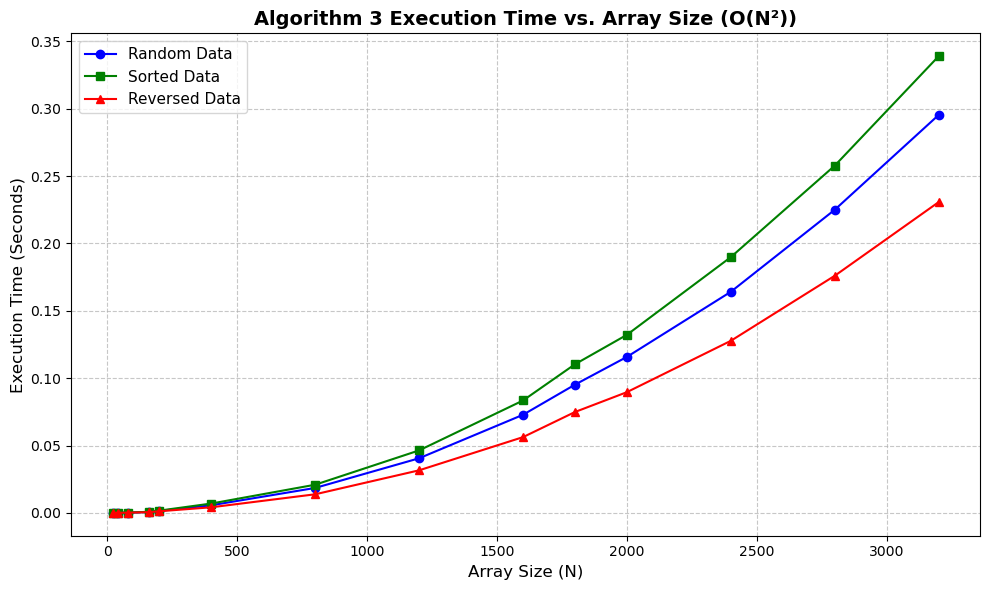

In [30]:
benchmark()

As the graph suggests, the time complexity is visually exponential with the input size $N$